# Learning the SIR Model from Stochastic Noise
**GSoC 2026 Project**

### Objective
To bridge the gap between stochastic (noisy) epidemic data and deterministic mathematical laws using Deep Learning and Symbolic Regression.

### Methodology
1. **Simulate:** Generate noisy epidemic data using the Gillespie Algorithm.
2. **Denoise:** Use an LSTM Neural Network to estimate parameters ($\beta, \gamma$).
3. **Discover:** Use SINDy (Sparse Identification of Nonlinear Dynamics) to recover the governing differential equations.

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import sys

# Add src to path so we can import our modules
# Note: Agar notebook 'notebooks' folder mein hai, toh '..' se root pe jayenge
sys.path.append(os.path.abspath(os.path.join('..')))

from src.models import SIR_LSTM
from src.simulation import gillespie_sir

print("Libraries Loaded Successfully! Kernel is Safe. ✅")

Libraries Loaded Successfully! Kernel is Safe. ✅


In [3]:
# Load Model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SIR_LSTM().to(DEVICE)
model.load_state_dict(torch.load("../saved_models/lstm_sir_v1.pth", map_location=DEVICE))
model.eval()
print("✅ Trained LSTM Model Loaded.")

✅ Trained LSTM Model Loaded.


Ground Truth Parameters: Beta=0.55, Gamma=0.15


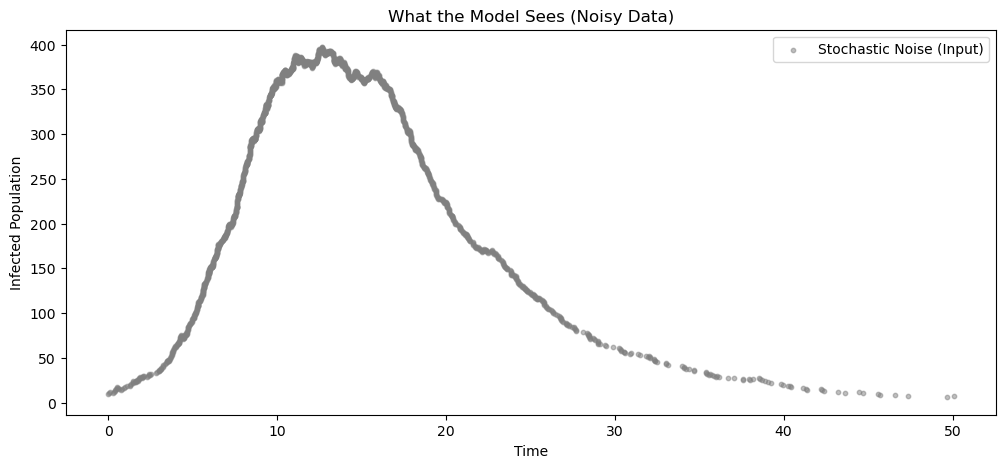

In [4]:
# Generate a random test case
true_beta = 0.55
true_gamma = 0.15
print(f"Ground Truth Parameters: Beta={true_beta}, Gamma={true_gamma}")

# Run Gillespie Simulation
t_sim, S_sim, I_sim, R_sim = gillespie_sir(990, 10, 0, true_beta, true_gamma, 50)

# Plot
plt.figure(figsize=(12, 5))
plt.scatter(t_sim, I_sim, c='gray', alpha=0.5, s=10, label="Stochastic Noise (Input)")
plt.title(f"What the Model Sees (Noisy Data)")
plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.legend()
plt.show()

🤖 Model Prediction:
Beta: 0.5984 (Error: 8.80%)
Gamma: 0.1415 (Error: 5.65%)


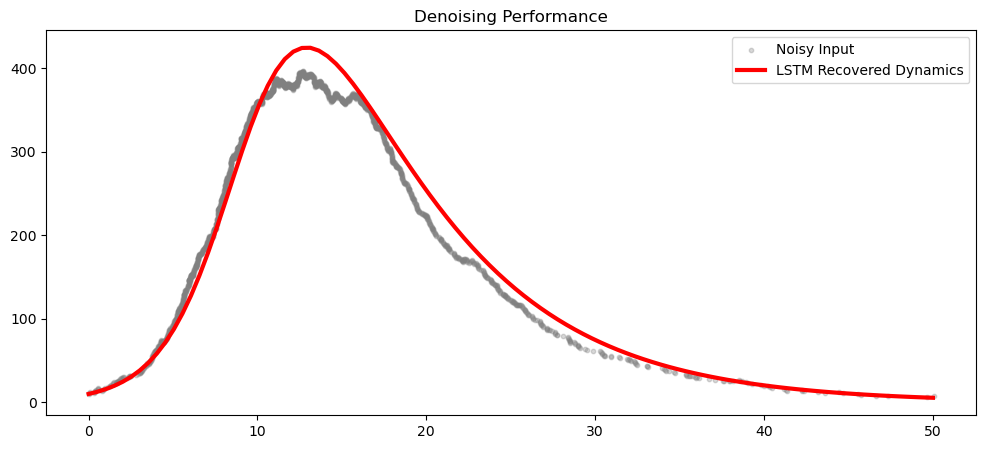

In [5]:
# Preprocess data for Model
N = 1000
t_fixed = np.linspace(0, 50, 100)
f_S = interp1d(t_sim, S_sim, kind='linear', fill_value="extrapolate")
f_I = interp1d(t_sim, I_sim, kind='linear', fill_value="extrapolate")
f_R = interp1d(t_sim, R_sim, kind='linear', fill_value="extrapolate")

input_tensor = np.stack([f_S(t_fixed)/N, f_I(t_fixed)/N, f_R(t_fixed)/N], axis=1)
input_tensor = torch.tensor(input_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

# Predict
with torch.no_grad():
    pred = model(input_tensor)
    
pred_beta = pred[0][0].item()
pred_gamma = pred[0][1].item()

print(f"🤖 Model Prediction:\nBeta: {pred_beta:.4f} (Error: {abs(true_beta-pred_beta)/true_beta*100:.2f}%)")
print(f"Gamma: {pred_gamma:.4f} (Error: {abs(true_gamma-pred_gamma)/true_gamma*100:.2f}%)")

# Plot Curve
def deriv(y, t, beta, gamma):
    s, i, r = y
    ds = -beta * s * i
    di = beta * s * i - gamma * i
    dr = gamma * i
    return ds, di, dr

y0 = [0.99, 0.01, 0.0]
sol = odeint(deriv, y0, t_fixed, args=(pred_beta, pred_gamma))

plt.figure(figsize=(12, 5))
plt.scatter(t_sim, I_sim, c='gray', alpha=0.3, s=10, label="Noisy Input")
plt.plot(t_fixed, sol[:, 1]*N, 'r-', linewidth=3, label="LSTM Recovered Dynamics")
plt.title("Denoising Performance")
plt.legend()
plt.show()

In [6]:
print("🔍 Discovering Differential Equations...")

# Use Cleaned Data from LSTM
X_clean = sol[:, :2] # Only S and I

# SINDy Setup
library = ps.PolynomialLibrary(degree=2, include_bias=False)
optimizer = ps.STLSQ(threshold=0.01, normalize_columns=True)
sindy_model = ps.SINDy(feature_library=library, optimizer=optimizer)

sindy_model.fit(X_clean, t=t_fixed)

print("\n--- Discovered Equations (x0=S, x1=I) ---")
sindy_model.print()

print(f"\nExpected Term for Infection: {pred_beta:.4f} * x0 * x1")
print(f"Expected Term for Recovery:  -{pred_gamma:.4f} * x1")

🔍 Discovering Differential Equations...

--- Discovered Equations (x0=S, x1=I) ---
(x0)' = -0.596 x0 x1 + -0.002 x1^2
(x1)' = -0.142 x1 +  0.596 x0 x1 +  0.003 x1^2

Expected Term for Infection: 0.5984 * x0 * x1
Expected Term for Recovery:  -0.1415 * x1
